## Quelles sont les bornes temporelles de la table audience ?

In [1]:
from load_data.donnees_chargement import load_audience

audience = load_audience()
audience.head()

,Annee,TF1,France 2,France 3,Arte
0,1989,41.0,23.4,10.3,NaN
1,1990,41.9,22.1,11.0,NaN
2,1991,42.1,21.3,11.3,NaN
3,1992,41.0,24.0,13.6,NaN
4,1993,41.0,24.7,14.6,0.9


In [2]:
max(audience["Annee"])

2024

In [3]:
min(audience["Annee"])

1989

Les données s'étendent entre 1989 et 2024

## Quelle est l'évolution de l'audience de chaque chaîne

<Axes: title={'center': "Audience totale en fonction de l'année"}, xlabel='Annee'>

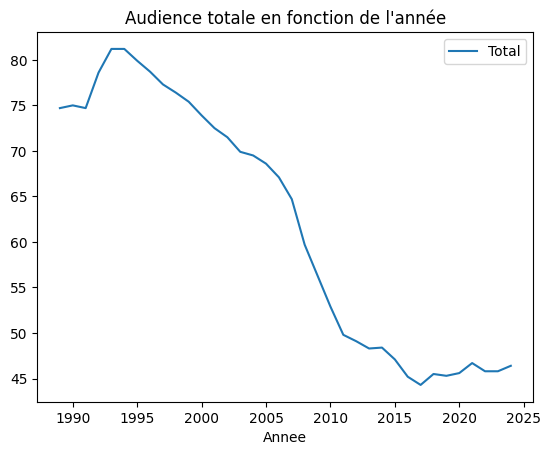

In [4]:
audience_par_annee = audience.drop(columns=["Annee"]).sum(axis=1)
audience["Total"] = audience_par_annee
audience.plot(x="Annee", y="Total", kind="line", title="Audience totale en fonction de l'année")

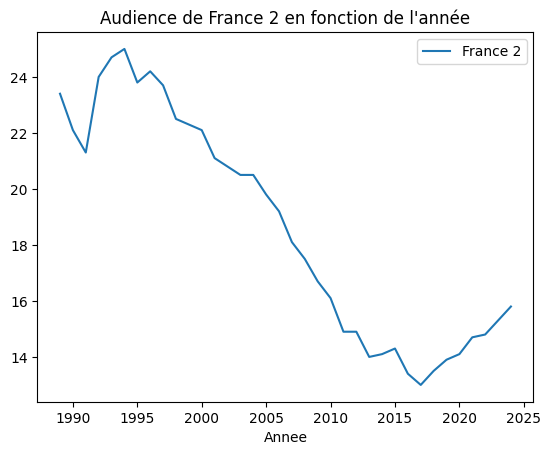

In [5]:
from utilities.utilities import audience_par_annee

audience_par_annee(audience, "Annee", "France 2")

<Axes: title={'center': "Comparaison de l'audience des chaînes TF1, France 2, France 3, Arte en fonction de l'année"}, xlabel='Annee'>

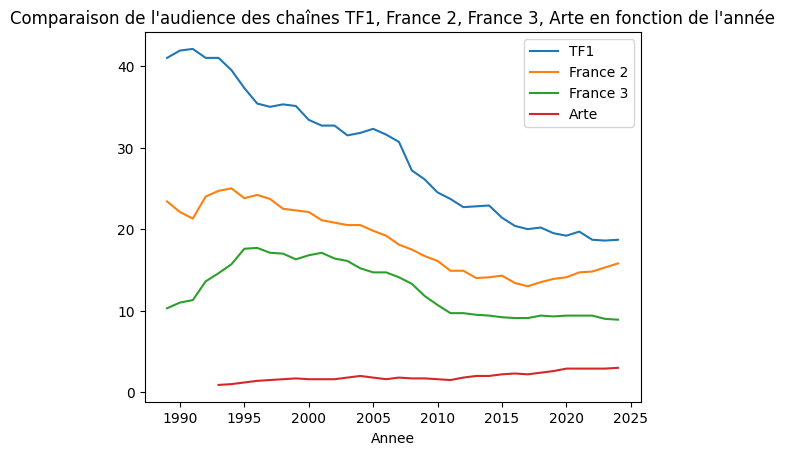

In [6]:
from utilities.utilities import comparaison_audience

comparaison_audience(audience, "Annee", ["TF1", "France 2", "France 3", "Arte"])

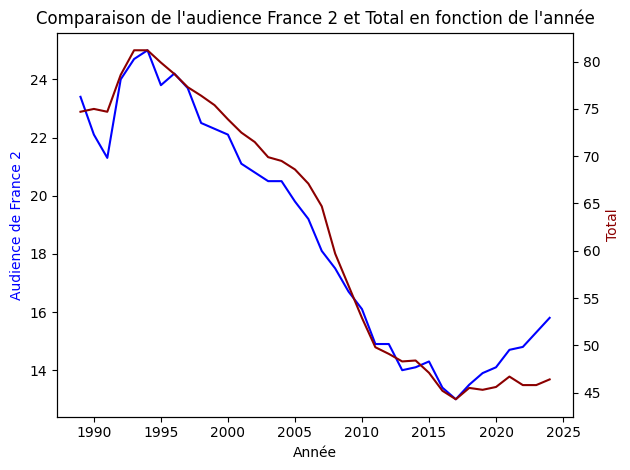

In [7]:
from utilities.utilities import comparaison_audience_axes

comparaison_audience_axes(audience, "Annee", "France 2", "Total")

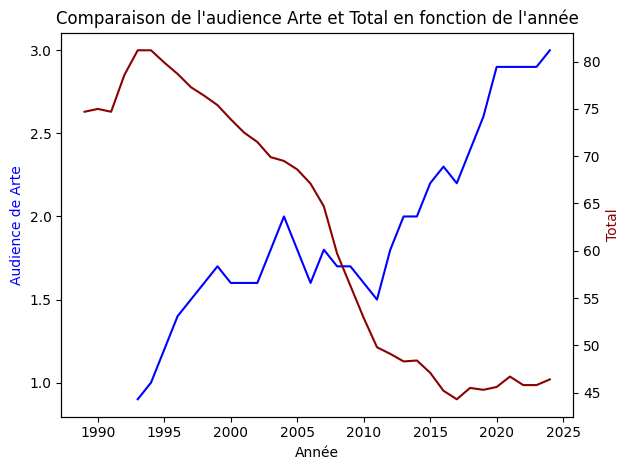

In [8]:
comparaison_audience_axes(audience, "Annee", "Arte", "Total")

# Analyse croisée avec sujet_tele

## Jointure des deux bases

In [9]:
from load_data.donnees_chargement import load_sujet_tele

sujet_tele = load_sujet_tele()
sujet_tele.head()

,Date,Chaîne,Thématique,Nb_sujets,Duree_sec,Temps_total_JT,Prop
0,2000-01-02,France 3,Catastrophes,2,235,1254,0.187400
1,2000-01-02,France 3,Culture-loisirs,1,138,1254,0.110048
2,2000-01-02,France 3,Environnement,3,306,1254,0.244019
3,2000-01-02,France 3,International,2,241,1254,0.192185
4,2000-01-02,France 3,Société,2,160,1254,0.127592


La table sujet_tele est au format long, il faut donc convertir audience en format long

In [10]:
audience_long = audience.melt(
    id_vars="Annee",
    var_name="Chaine",
    value_name="Audience"
)

In [11]:
audience_long.head()

,Annee,Chaine,Audience
0,1989,TF1,41.0
1,1990,TF1,41.9
2,1991,TF1,42.1
3,1992,TF1,41.0
4,1993,TF1,41.0


La table sujet_annee date les évènements par jour. Convertissons les en années

In [12]:
from utilities.utilities import sujet_convert
from load_data.donnees_chargement import load_sujet_tele

sujet_tele_year = sujet_convert(indic='Y', table = load_sujet_tele())
sujet_tele_year["Date"] = sujet_tele_year["Date"].astype(str).astype(int)

In [13]:
sujet_tele_year.head()

,Date,Chaîne,Thématique,Temps cumul,Temps moyen
0,2000,Arte,Catastrophes,9328,89.692308
1,2000,Arte,Culture-loisirs,53981,213.363636
2,2000,Arte,Economie,34342,180.747368
3,2000,Arte,Education,3641,173.380952
4,2000,Arte,Environnement,15859,153.970874


Jointure des deux tables.

In [14]:
import pandas as pd

sujet_audience = pd.merge(sujet_tele_year, 
                          audience_long, 
                          left_on=["Date", "Chaîne"], 
                          right_on=["Annee", "Chaine"]
                          ).drop(columns=["Annee", "Chaine"])

In [15]:
sujet_audience.head()

,Date,Chaîne,Thématique,Temps cumul,Temps moyen,Audience
0,2000,Arte,Catastrophes,9328,89.692308,1.6
1,2000,Arte,Culture-loisirs,53981,213.363636,1.6
2,2000,Arte,Economie,34342,180.747368,1.6
3,2000,Arte,Education,3641,173.380952,1.6
4,2000,Arte,Environnement,15859,153.970874,1.6


## Analyse 

### Croisement thématique/audience par chaîne

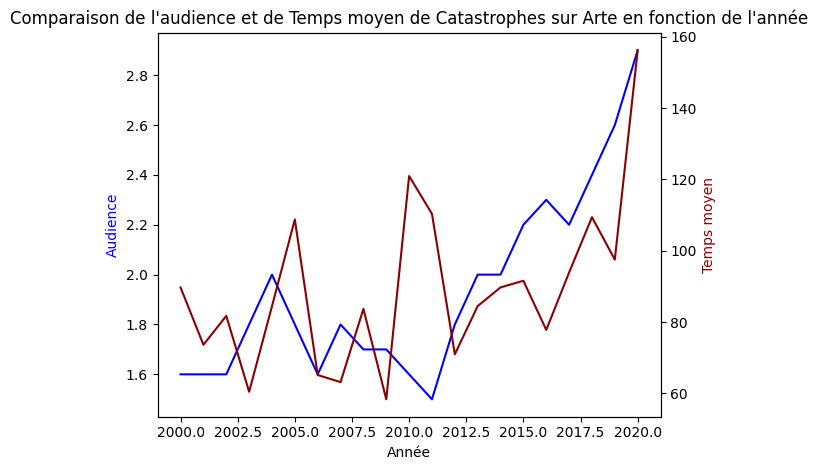

In [17]:
from utilities.utilities import evolution_audience_sujet_chaine

evolution_audience_sujet_chaine(sujet_audience, "Catastrophes", "Arte")

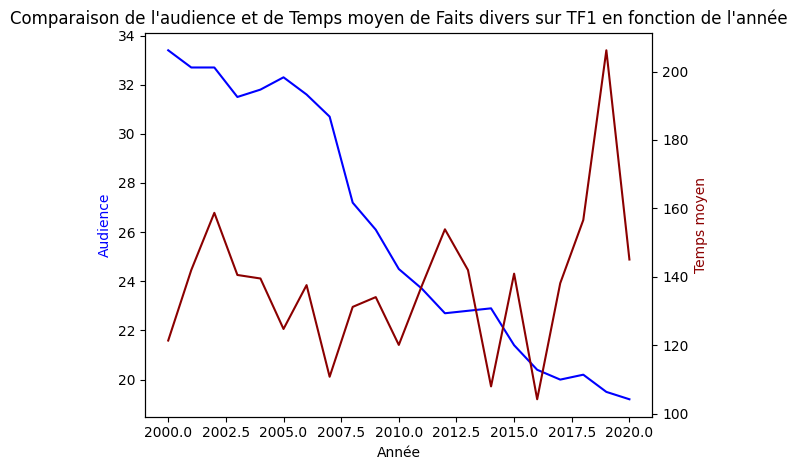

In [26]:
evolution_audience_sujet_chaine(sujet_audience, "Faits divers", "TF1")

### Croisement thématique/audience total